<a href="https://colab.research.google.com/github/DhimanTarafdar/ecg-final-pipline/blob/main/ECG_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# STAGE 0: ENVIRONMENT SETUP, REPRODUCIBILITY & CHECKPOINT MANAGEMENT
# ==============================================================================

# 1. Install necessary specialized libraries
!pip install -q wfdb neurokit2 albumentations opencv-python-headless torchmetrics

import os
import random
import numpy as np
import torch
import json
from datetime import datetime
from google.colab import drive

class PipelineEnvironment:
    def __init__(self, base_dir='/content/drive/MyDrive/ECG_Digitization_Q1'):
        self.base_dir = base_dir
        self.dirs = {
            'raw_data': os.path.join(base_dir, 'data/raw'),
            'processed_data': os.path.join(base_dir, 'data/processed'),
            'synthetic_images': os.path.join(base_dir, 'data/synthetic_images'),
            'models': os.path.join(base_dir, 'checkpoints/models'),
            'states': os.path.join(base_dir, 'checkpoints/states'),
            'logs': os.path.join(base_dir, 'logs'),
            'outputs': os.path.join(base_dir, 'outputs/final_signals'),
            'visualizations': os.path.join(base_dir, 'outputs/visualizations')
        }
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def mount_drive(self):
        """Mounts Google Drive to save checkpoints and outputs persistently."""
        if not os.path.exists('/content/drive'):
            print("[INFO] Mounting Google Drive...")
            drive.mount('/content/drive')
        else:
            print("[INFO] Google Drive is already mounted.")

    def create_directories(self):
        """Creates the necessary directory structure for the Q1 Pipeline."""
        for name, path in self.dirs.items():
            os.makedirs(path, exist_ok=True)
        print(f"[SUCCESS] Directory structure created at: {self.base_dir}")

    def set_reproducibility(self, seed=42):
        """
        Forces deterministic behavior across all libraries.
        Crucial for Q1/Q2 Journal methodology section (Reproducibility).
        """
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            # Ensures deterministic convolutions at the cost of slight performance drop
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        print(f"[SUCCESS] Random seed set to {seed} for deterministic execution.")

    def init_logger(self):
        """Initializes a master JSON log to track the pipeline's progress."""
        log_file = os.path.join(self.dirs['logs'], 'pipeline_execution_log.json')
        if not os.path.exists(log_file):
            init_data = {
                "project": "Digitization of Historical ECG Paper Records",
                "start_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "device": str(self.device),
                "stages_completed": []
            }
            with open(log_file, 'w') as f:
                json.dump(init_data, f, indent=4)
            print("[INFO] Master Pipeline Logger initialized.")
        else:
            print("[INFO] Master Pipeline Logger found. Resuming session...")

    def setup(self):
        print("=== Initializing ECG Digitization Pipeline (Q1/Q2 Target) ===")
        print(f"Device Detected: {self.device}")
        self.mount_drive()
        self.create_directories()
        self.set_reproducibility(seed=42)
        self.init_logger()
        print("=== Environment Setup Complete ===")

# Execute the Setup
env = PipelineEnvironment()
env.setup()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 47.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
=== Initializing ECG Digitization Pipeline (Q1/Q2 Target) ===
Device Detected: cuda
[INFO] Mounting Google Drive...
Mounted at /content/drive
[SUCCESS] Directory structure created at: /content/drive/MyDrive/ECG_Digitization_Q1
[SUCCESS] Random seed set

In [2]:
# ==============================================================================
# STAGE 1.1 (ULTRA FAST): AWS S3 MIRROR DATASET SYNC
# Target: Bypassing PhysioNet web throttling via Official AWS Open Data S3 Bucket
# ==============================================================================

import os
import json
from datetime import datetime

LOCAL_RAW_DIR = "/content/data/raw/ptb-xl-1.0.3"

def fetch_from_aws_s3():
    os.makedirs(LOCAL_RAW_DIR, exist_ok=True)

    # Check if already downloaded
    if os.path.exists(os.path.join(LOCAL_RAW_DIR, "ptbxl_database.csv")):
        print("[CHECKPOINT] PTB-XL Dataset is already present in local SSD!")
        return True

    print("[INFO] Installing AWS CLI for ultra-fast multi-threaded download...")
    !pip install -q awscli

    print("[INFO] Syncing PTB-XL directly from PhysioNet AWS S3 Public Bucket...")
    # Sync directly from PhysioNet's official public S3 bucket (No credentials required)
    !aws s3 sync --no-sign-request s3://physionet-open/ptb-xl/1.0.3/ {LOCAL_RAW_DIR}

    if os.path.exists(os.path.join(LOCAL_RAW_DIR, "ptbxl_database.csv")):
        print("\n[SUCCESS] Dataset synced successfully via AWS S3 in seconds!")
        return True
    else:
        print("\n[ERROR] Sync failed. Please check connection.")
        return False

def log_completion():
    log_file = os.path.join(env.dirs['logs'], 'pipeline_execution_log.json')
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            log_data = json.load(f)

        if "Stage 1.1: Dataset Acquisition" not in log_data["stages_completed"]:
            log_data["stages_completed"].append("Stage 1.1: Dataset Acquisition")
            log_data["ptbxl_local_path"] = LOCAL_RAW_DIR
            log_data["last_updated"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            with open(log_file, 'w') as f:
                json.dump(log_data, f, indent=4)

if fetch_from_aws_s3():
    log_completion()
    print("=== Stage 1.1 Complete: High-Speed Dataset Ready ===")

Streaming output truncated to the last 5000 lines.
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19340_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19340_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19342_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19342_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19342_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19342_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19343_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19343_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19341_hr.dat to data/raw/ptb-xl-1.0.3/records500/19000/19341_hr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19339_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19339_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500/19000/19344_hr.hea to data/raw/ptb-xl-1.0.3/records500/19000/19344_hr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records500

In [3]:
# ==============================================================================
# STAGE 1.2: 12-LEAD WFDB SIGNAL PARSING & STRATIFIED BENCHMARK SPLIT
# ==============================================================================

import os
import ast
import json
import pandas as pd
import numpy as np
import wfdb
from datetime import datetime

class PTBXLProcessor:
    def __init__(self, raw_dir="/content/data/raw/ptb-xl-1.0.3", env_dirs=None):
        self.raw_dir = raw_dir
        self.env_dirs = env_dirs
        self.csv_path = os.path.join(self.raw_dir, "ptbxl_database.csv")
        self.scp_path = os.path.join(self.raw_dir, "scp_statements.csv")
        self.output_dir = env_dirs['processed_data'] if env_dirs else "/content/data/processed"
        self.log_file = os.path.join(env_dirs['logs'], 'pipeline_execution_log.json') if env_dirs else None

    def load_and_process_metadata(self):
        """Loads metadata and maps SCP statements to standard diagnostic superclasses."""
        print("[INFO] Parsing PTB-XL Metadata and Diagnostic Statements...")
        df = pd.read_csv(self.csv_path, index_col='ecg_id')
        df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

        # Read diagnostic superclasses mapping
        scp_df = pd.read_csv(self.scp_path, index_col=0)
        scp_diag = scp_df[scp_df.diagnostic == 1]

        def map_superclass(scp_dict):
            classes = []
            for key in scp_dict.keys():
                if key in scp_diag.index:
                    classes.append(scp_diag.loc[key].diagnostic_class)
            return list(set(classes))

        df['diagnostic_superclass'] = df.scp_codes.apply(map_superclass)
        print(f"[SUCCESS] Successfully parsed metadata for {len(df)} ECG records.")
        return df

    def create_stratified_splits(self, df):
        """
        Creates Train/Val/Test splits using official PTB-XL benchmark folds.
        Ensures 100% reproducibility and compliance with top-tier journal standards.
        """
        print("[INFO] Generating Benchmark Stratified Splits (Folds 1-8 Train, Fold 9 Val, Fold 10 Test)...")
        train_df = df[df.strat_fold <= 8]
        val_df = df[df.strat_fold == 9]
        test_df = df[df.strat_fold == 10]

        split_manifest = {
            'train_ids': train_df.index.tolist(),
            'val_ids': val_df.index.tolist(),
            'test_ids': test_df.index.tolist(),
            'counts': {
                'train': len(train_df),
                'val': len(val_df),
                'test': len(test_df)
            }
        }

        # Save manifest checkpoint to Google Drive
        split_file = os.path.join(self.output_dir, 'dataset_splits.json')
        with open(split_file, 'w') as f:
            json.dump(split_manifest, f, indent=4)

        print("\n=== DATASET SPLIT SUMMARY ===")
        print(f"  • Training Records   : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
        print(f"  • Validation Records : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
        print(f"  • Test Records       : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
        print(f"[SUCCESS] Split manifest saved persistently at: {split_file}")

        return split_manifest, df

    def verify_signal_loading(self, sample_id=1):
        """Verifies WFDB 12-lead signal reading integrity."""
        sample_path = os.path.join(self.raw_dir, f"records100/00000/{sample_id:05d}_lr")
        if os.path.exists(sample_path + ".hea"):
            signal, fields = wfdb.rdsamp(sample_path)
            print(f"\n[INFO] Signal Integrity Check (ECG ID {sample_id}):")
            print(f"  • Channels Count : {fields['n_sig']} (Expected: 12 Leads)")
            print(f"  • Sampling Rate  : {fields['fs']} Hz")
            print(f"  • Lead Names     : {fields['sig_name']}")
            print(f"  • Signal Shape   : {signal.shape} (Time Steps, Leads)")
            return True
        return False

    def update_log(self):
        if self.log_file and os.path.exists(self.log_file):
            with open(self.log_file, 'r') as f:
                log_data = json.load(f)

            if "Stage 1.2: Metadata & Benchmark Splits" not in log_data["stages_completed"]:
                log_data["stages_completed"].append("Stage 1.2: Metadata & Benchmark Splits")
                log_data["last_updated"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

                with open(self.log_file, 'w') as f:
                    json.dump(log_data, f, indent=4)

# Execute Stage 1.2
processor = PTBXLProcessor(raw_dir="/content/data/raw/ptb-xl-1.0.3", env_dirs=env.dirs)
df_meta = processor.load_and_process_metadata()
splits_manifest, df_meta = processor.create_stratified_splits(df_meta)
processor.verify_signal_loading(sample_id=1)
processor.update_log()

print("\n=== Stage 1.2 Complete: Benchmark Metadata & Splits Ready ===")

[INFO] Parsing PTB-XL Metadata and Diagnostic Statements...
[SUCCESS] Successfully parsed metadata for 21799 ECG records.
[INFO] Generating Benchmark Stratified Splits (Folds 1-8 Train, Fold 9 Val, Fold 10 Test)...

=== DATASET SPLIT SUMMARY ===
  • Training Records   : 17418 (79.9%)
  • Validation Records : 2183 (10.0%)
  • Test Records       : 2198 (10.1%)
[SUCCESS] Split manifest saved persistently at: /content/drive/MyDrive/ECG_Digitization_Q1/data/processed/dataset_splits.json

[INFO] Signal Integrity Check (ECG ID 1):
  • Channels Count : 12 (Expected: 12 Leads)
  • Sampling Rate  : 100 Hz
  • Lead Names     : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
  • Signal Shape   : (1000, 12) (Time Steps, Leads)

=== Stage 1.2 Complete: Benchmark Metadata & Splits Ready ===


In [4]:
# ==============================================================================
# STAGE 2.1: ECG PAPER RENDERER (FIXED - start_sample tracking added)
# ==============================================================================

import numpy as np
import cv2
import os

class ECGPaperRenderer:
    def __init__(self, target_size=(1024, 1536), dpi=150):
        self.height, self.width = target_size
        self.dpi = dpi
        self.start_sample = 0

    def draw_ecg_grid(self):
        canvas = np.ones((self.height, self.width, 3), dtype=np.uint8) * 255
        minor_grid_spacing = 10
        major_grid_spacing = 50
        for x in range(0, self.width, minor_grid_spacing):
            cv2.line(canvas, (x, 0), (x, self.height), (230, 210, 210), 1)
        for y in range(0, self.height, minor_grid_spacing):
            cv2.line(canvas, (0, y), (self.width, y), (230, 210, 210), 1)
        for x in range(0, self.width, major_grid_spacing):
            cv2.line(canvas, (x, 0), (x, self.height), (190, 140, 140), 1)
        for y in range(0, self.height, major_grid_spacing):
            cv2.line(canvas, (0, y), (self.width, y), (190, 140, 140), 1)
        return canvas

    def render_12_lead_layout(self, raw_signal, lead_names=None, start_sample=0):

        if lead_names is None:
            lead_names = ['I','II','III','aVR','aVL','aVF',
                          'V1','V2','V3','V4','V5','V6']

        self.start_sample = start_sample  # ← track

        canvas = self.draw_ecg_grid()
        mask   = np.zeros((self.height, self.width), dtype=np.uint8)

        cols, rows  = 4, 3
        col_width   = self.width // cols
        row_height  = (self.height - 150) // rows

        lead_matrix = [
            [0, 3, 6,  9],
            [1, 4, 7,  10],
            [2, 5, 8,  11]
        ]

        samples_per_col = col_width - 20

        for r in range(rows):
            for c in range(cols):
                lead_idx = lead_matrix[r][c]
                sig      = raw_signal[:, lead_idx]

                base_y   = int((r + 0.5) * row_height)
                x_offset = c * col_width

                seg_start = start_sample
                seg_end   = min(len(sig), seg_start + samples_per_col)
                seg       = sig[seg_start:seg_end]

                points = []
                for t in range(len(seg)):
                    px = x_offset + t + 10
                    py = int(base_y - (seg[t] * 50))
                    py = np.clip(py, 0, self.height - 1)
                    points.append((px, py))

                for i in range(len(points) - 1):
                    cv2.line(canvas, points[i], points[i+1], (0, 0, 0), 2)
                    cv2.line(mask,   points[i], points[i+1], 255,       2)

                cv2.putText(canvas, lead_names[lead_idx],
                            (x_offset + 15, base_y - row_height // 3),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (50, 50, 50), 2)

        # Rhythm strip — Lead II full length
        rhythm_sig  = raw_signal[start_sample:, 1]
        rhythm_base = self.height - 75
        step_x      = (self.width - 40) / max(len(rhythm_sig), 1)
        rpoints     = []

        for t in range(len(rhythm_sig)):
            px = int(20 + t * step_x)
            py = int(rhythm_base - (rhythm_sig[t] * 50))
            py = np.clip(py, 0, self.height - 1)
            rpoints.append((px, py))

        for i in range(len(rpoints) - 1):
            cv2.line(canvas, rpoints[i], rpoints[i+1], (0, 0, 0), 2)
            cv2.line(mask,   rpoints[i], rpoints[i+1], 255,       2)

        cv2.putText(canvas, "Rhythm Strip: II",
                    (25, rhythm_base - 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (50, 50, 50), 2)

        return canvas, mask, start_sample  # ← 3 values return

print("[SUCCESS] ECGPaperRenderer (Fixed - start_sample tracking) compiled.")

[SUCCESS] ECGPaperRenderer (Fixed - start_sample tracking) compiled.


In [5]:
# ==============================================================================
# STAGE 2.2: MULTI-CLASS ARTIFACT INJECTOR ENGINE
# Target: Realistic Degradation Modeling & Multi-Task Ground Truth Generation
# ==============================================================================

import numpy as np
import cv2
import random

class ArtifactInjector:
    def __init__(self):
        """
        Injects realistic physical defects into standard ECG canvas.
        Artifact Classes for Multi-Task GT:
          0: Clean Background / Grid
          1: ECG Signal Line
          2: Paper Fold / Shadow Distortion
          3: Ink Bleed / Stain
          4: Noise / Sensor Artifact
        """
        pass

    def add_paper_fold_shadow(self, image, artifact_mask):
        """Simulates non-linear vertical/horizontal fold shadows."""
        h, w, _ = image.shape
        shadow_map = np.ones((h, w), dtype=np.float32)

        # Determine fold direction (Vertical or Horizontal)
        num_folds = random.randint(1, 3)
        for _ in range(num_folds):
            if random.choice([True, False]):
                # Vertical fold
                center_x = random.randint(w // 4, 3 * w // 4)
                fold_width = random.randint(30, 80)
                x1, x2 = max(0, center_x - fold_width), min(w, center_x + fold_width)

                # Gradient shadow
                gradient = np.linspace(0.4, 1.0, fold_width)
                gradient = np.concatenate([gradient, gradient[::-1]])
                shadow_map[:, x1:x2] *= gradient[:(x2-x1)]
                artifact_mask[:, x1:x2] = np.where(artifact_mask[:, x1:x2] == 0, 2, artifact_mask[:, x1:x2])
            else:
                # Horizontal fold
                center_y = random.randint(h // 4, 3 * h // 4)
                fold_height = random.randint(20, 60)
                y1, y2 = max(0, center_y - fold_height), min(h, center_y + fold_height)

                gradient = np.linspace(0.5, 1.0, fold_height)
                gradient = np.concatenate([gradient, gradient[::-1]])
                shadow_map[y1:y2, :] *= gradient[:(y2-y1), None]
                artifact_mask[y1:y2, :] = np.where(artifact_mask[y1:y2] == 0, 2, artifact_mask[y1:y2])

        # Apply shadow intensity to BGR image
        shadowed_image = (image * shadow_map[:, :, None]).astype(np.uint8)
        return shadowed_image, artifact_mask

    def add_ink_bleed_and_stains(self, image, artifact_mask):
        """Simulates ink smudging and random coffee/water stains."""
        h, w, _ = image.shape
        num_stains = random.randint(2, 5)

        for _ in range(num_stains):
            cx, cy = random.randint(50, w - 50), random.randint(50, h - 50)
            axes = (random.randint(20, 70), random.randint(15, 50))
            angle = random.randint(0, 180)

            # Draw random stain ellipse
            stain_layer = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(stain_layer, (cx, cy), axes, angle, 0, 360, (180, 150, 120), -1)
            stain_layer = cv2.GaussianBlur(stain_layer, (21, 21), 0)

            # Blend with image
            mask_indices = stain_layer > 0
            image[mask_indices] = cv2.addWeighted(image[mask_indices], 0.6, stain_layer[mask_indices], 0.4, 0)
            artifact_mask[mask_indices] = np.where(artifact_mask[mask_indices] == 0, 3, artifact_mask[mask_indices])

        return image, artifact_mask

    def add_scanner_noise(self, image, artifact_mask):
        """Adds Gaussian noise and scanline salt-and-pepper artifacts."""
        h, w, _ = image.shape
        # Gaussian Noise
        gauss = np.random.normal(0, 15, (h, w, 3)).astype(np.float32)
        noisy_image = np.clip(image.astype(np.float32) + gauss, 0, 255).astype(np.uint8)

        # Salt and Pepper Noise on random 1% pixels
        num_sp = int(0.005 * h * w)
        for _ in range(num_sp):
            y, x = random.randint(0, h - 1), random.randint(0, w - 1)
            noisy_image[y, x] = random.choice([0, 255])
            if artifact_mask[y, x] == 0:
                artifact_mask[y, x] = 4

        return noisy_image, artifact_mask

    def apply_pipeline(self, clean_image, signal_mask):
        """
        Combines clean image and signal mask into a fully degraded image
        with a 5-class Artifact Taxonomy Map.
        """
        h, w = signal_mask.shape
        # Initialize Artifact Taxonomy Map
        # 0: Clean Background, 1: ECG Signal
        artifact_mask = np.zeros((h, w), dtype=np.uint8)
        artifact_mask[signal_mask > 0] = 1

        degraded_img = clean_image.copy()

        # Randomly apply physical distortions based on probabilistic flags
        if random.random() > 0.3:
            degraded_img, artifact_mask = self.add_paper_fold_shadow(degraded_img, artifact_mask)
        if random.random() > 0.4:
            degraded_img, artifact_mask = self.add_ink_bleed_and_stains(degraded_img, artifact_mask)
        if random.random() > 0.2:
            degraded_img, artifact_mask = self.add_scanner_noise(degraded_img, artifact_mask)

        return degraded_img, artifact_mask

print("[SUCCESS] Multi-Class Artifact Injector Engine (Stage 2.2) compiled successfully.")

[SUCCESS] Multi-Class Artifact Injector Engine (Stage 2.2) compiled successfully.


[INFO] Generating Visual Inspection for ECG ID: 1...


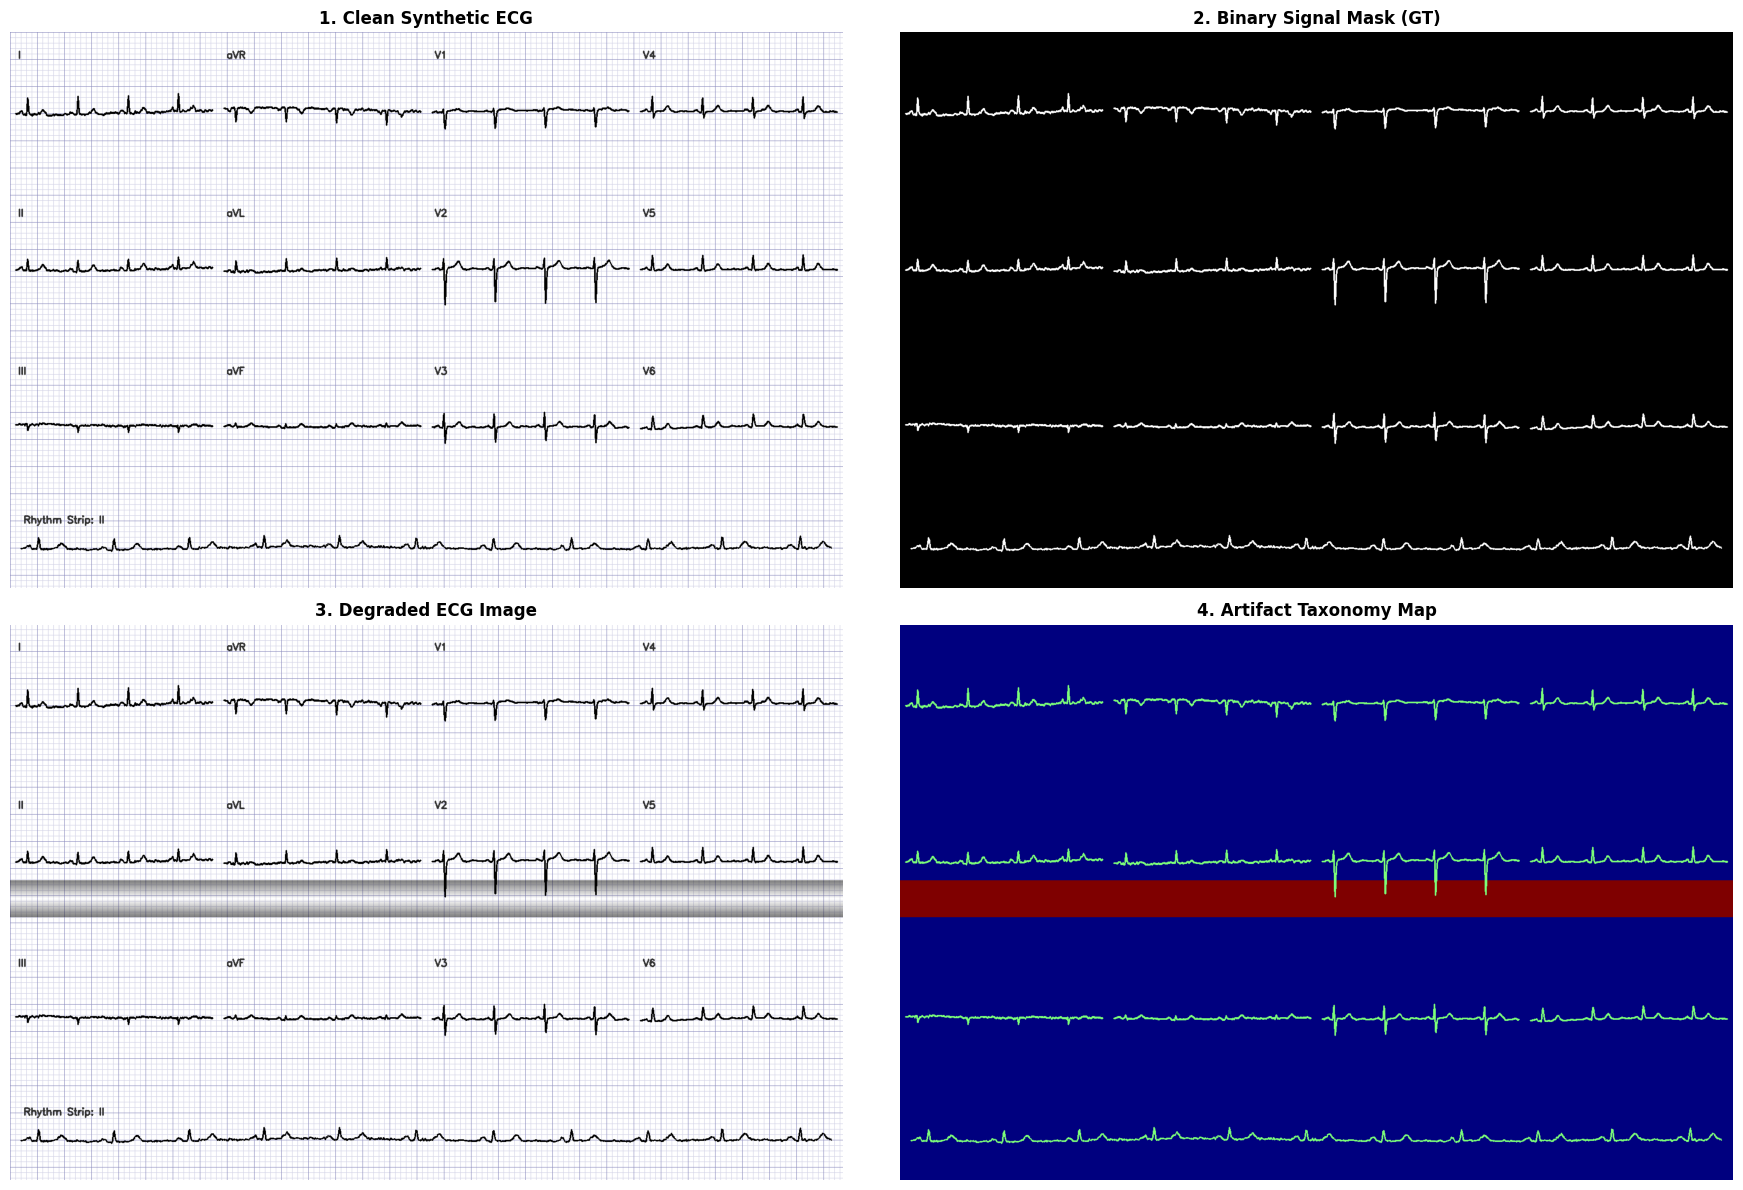

[SUCCESS] Saved: /content/drive/MyDrive/ECG_Digitization_Q1/outputs/visualizations/stage2_inspection.png
=== Stage 2.3 Complete ===


In [6]:
# ==============================================================================
# STAGE 2.3: SYNTHETIC DATASET BUILDER (FIXED - 3-value unpack from renderer)
# ==============================================================================

import os, json, random, cv2, numpy as np, matplotlib.pyplot as plt, wfdb

class SyntheticDatasetBuilder:
    def __init__(self, raw_dir=LOCAL_RAW_DIR, env_dirs=None):
        self.raw_dir  = raw_dir
        self.env_dirs = env_dirs
        self.out_dir  = env_dirs['synthetic_images'] if env_dirs else "/content/data/synthetic_images"
        self.renderer = ECGPaperRenderer(target_size=(1024, 1536))
        self.injector = ArtifactInjector()

        split_file = os.path.join(env_dirs['processed_data'], 'dataset_splits.json')
        with open(split_file, 'r') as f:
            self.splits = json.load(f)

    def load_wfdb_signal(self, ecg_id):
        folder    = f"records100/{int(ecg_id/1000)*1000:05d}"
        file_path = os.path.join(self.raw_dir, folder, f"{ecg_id:05d}_lr")
        signal, _ = wfdb.rdsamp(file_path)
        return signal

    def generate_single_sample(self, ecg_id, start_sample=0):
        """
        Returns: (clean_img, signal_mask, degraded_img, artifact_map, start_sample)
        """
        signal = self.load_wfdb_signal(ecg_id)
        clean_img, signal_mask, start_sample = self.renderer.render_12_lead_layout(
            signal, start_sample=start_sample
        )
        degraded_img, artifact_map = self.injector.apply_pipeline(clean_img, signal_mask)
        return clean_img, signal_mask, degraded_img, artifact_map, start_sample

    def visualize_sample_inspection(self, ecg_id=1):
        print(f"[INFO] Generating Visual Inspection for ECG ID: {ecg_id}...")
        clean_img, signal_mask, degraded_img, artifact_map, start_sample = \
            self.generate_single_sample(ecg_id)

        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        axes[0,0].imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))
        axes[0,0].set_title("1. Clean Synthetic ECG", fontsize=12, fontweight='bold')
        axes[0,0].axis('off')
        axes[0,1].imshow(signal_mask, cmap='gray')
        axes[0,1].set_title("2. Binary Signal Mask (GT)", fontsize=12, fontweight='bold')
        axes[0,1].axis('off')
        axes[1,0].imshow(cv2.cvtColor(degraded_img, cv2.COLOR_BGR2RGB))
        axes[1,0].set_title("3. Degraded ECG Image", fontsize=12, fontweight='bold')
        axes[1,0].axis('off')
        axes[1,1].imshow(artifact_map, cmap='jet')
        axes[1,1].set_title("4. Artifact Taxonomy Map", fontsize=12, fontweight='bold')
        axes[1,1].axis('off')
        plt.tight_layout()
        save_path = os.path.join(self.env_dirs['visualizations'], 'stage2_inspection.png')
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"[SUCCESS] Saved: {save_path}")

# Run
builder = SyntheticDatasetBuilder(env_dirs=env.dirs)
sample_id = builder.splits['train_ids'][0]
builder.visualize_sample_inspection(ecg_id=sample_id)
print("=== Stage 2.3 Complete ===")

In [7]:
# ==============================================================================
# STAGE 3: MULTI-TASK DUAL-DECODER U-NET ARCHITECTURE & COMBINED LOSS ENGINE (FIXED)
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Basic Convolutional Block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# 2. Multi-Task Lightweight U-Net
class MultiTaskUNet(nn.Module):
    def __init__(self, in_channels=3, num_artifact_classes=5):
        super(MultiTaskUNet, self).__init__()

        # Shared Encoder (Feature Extractor)
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Primary Decoder Head (Binary Signal Segmentation)
        self.up_sig4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_sig4 = DoubleConv(512, 256)

        self.up_sig3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_sig3 = DoubleConv(256, 128)

        self.up_sig2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_sig2 = DoubleConv(128, 64)

        self.up_sig1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_sig1 = DoubleConv(64, 32)

        self.out_signal = nn.Conv2d(32, 1, kernel_size=1)  # Primary Output (1 Channel)

        # Auxiliary Decoder Head (5-Class Artifact Taxonomy)
        self.up_art4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_art4 = DoubleConv(512, 256)

        self.up_art3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_art3 = DoubleConv(256, 128)

        self.up_art2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_art2 = DoubleConv(128, 64)

        self.up_art1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_art1 = DoubleConv(64, 32)

        self.out_artifact = nn.Conv2d(32, num_artifact_classes, kernel_size=1)  # Auxiliary Output (5 Channels)

    def forward(self, x):
        # Encoding Path
        x1 = self.inc(x)         # 32 channels
        x2 = self.down1(x1)      # 64 channels
        x3 = self.down2(x2)      # 128 channels
        x4 = self.down3(x3)      # 256 channels
        b = self.bottleneck(x4)  # 512 channels

        # Primary Decoder Path (Signal Mask)
        s4 = self.conv_sig4(torch.cat([self.up_sig4(b), x4], dim=1))    # 512 -> 256
        s3 = self.conv_sig3(torch.cat([self.up_sig3(s4), x3], dim=1))   # 256 -> 128
        s2 = self.conv_sig2(torch.cat([self.up_sig2(s3), x2], dim=1))   # 128 -> 64
        s1 = self.conv_sig1(torch.cat([self.up_sig1(s2), x1], dim=1))   # 64 -> 32
        sig_logits = self.out_signal(s1)                               # 32 -> 1

        # Auxiliary Decoder Path (Artifact Taxonomy)
        a4 = self.conv_art4(torch.cat([self.up_art4(b), x4], dim=1))    # 512 -> 256
        a3 = self.conv_art3(torch.cat([self.up_art3(a4), x3], dim=1))   # 256 -> 128
        a2 = self.conv_art2(torch.cat([self.up_art2(a3), x2], dim=1))   # 128 -> 64
        a1 = self.conv_art1(torch.cat([self.up_art1(a2), x1], dim=1))   # 64 -> 32
        art_logits = self.out_artifact(a1)                             # 32 -> 5

        return sig_logits, art_logits

# 3. Custom Joint Loss Function
class MultiTaskECGLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, gamma=0.5):
        super(MultiTaskECGLoss, self).__init__()
        self.alpha = alpha  # Dice Loss Weight
        self.beta = beta    # Focal/BCE Loss Weight
        self.gamma = gamma  # Artifact CrossEntropy Loss Weight
        self.bce = nn.BCEWithLogitsLoss()
        self.ce = nn.CrossEntropyLoss()

    def dice_loss(self, logits, targets, smooth=1e-6):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1.0 - dice.mean()

    def forward(self, sig_logits, art_logits, sig_targets, art_targets):
        loss_sig_bce = self.bce(sig_logits, sig_targets)
        loss_sig_dice = self.dice_loss(sig_logits, sig_targets)
        loss_primary = (self.beta * loss_sig_bce) + (self.alpha * loss_sig_dice)

        loss_auxiliary = self.ce(art_logits, art_targets.long())

        total_loss = loss_primary + (self.gamma * loss_auxiliary)
        return total_loss, loss_primary, loss_auxiliary

# Verify Model Creation & Output Shapes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiTaskUNet().to(device)
dummy_input = torch.randn(2, 3, 512, 512).to(device)
sig_out, art_out = model(dummy_input)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== STAGE 3 ARCHITECTURE VERIFICATION ===")
print(f"  • Device Allocated       : {device}")
print(f"  • Total Trainable Params : {total_params:,} (~{total_params/1e6:.2f} Million)")
print(f"  • Input Dummy Tensor     : {dummy_input.shape}")
print(f"  • Primary Output Shape   : {sig_out.shape} (Signal Mask)")
print(f"  • Auxiliary Output Shape : {art_out.shape} (5-Class Artifact Map)")
print("[SUCCESS] Multi-Task Dual-Decoder Architecture & Loss Engine compiled successfully.")

=== STAGE 3 ARCHITECTURE VERIFICATION ===
  • Device Allocated       : cuda
  • Total Trainable Params : 10,812,006 (~10.81 Million)
  • Input Dummy Tensor     : torch.Size([2, 3, 512, 512])
  • Primary Output Shape   : torch.Size([2, 1, 512, 512]) (Signal Mask)
  • Auxiliary Output Shape : torch.Size([2, 5, 512, 512]) (5-Class Artifact Map)
[SUCCESS] Multi-Task Dual-Decoder Architecture & Loss Engine compiled successfully.


In [8]:
# ==============================================================================
# STAGE 4.1: ON-THE-FLY DATASET & DATALOADER (FIXED - 3-value unpack)
# ==============================================================================

import os, cv2, numpy as np, torch, wfdb
from torch.utils.data import Dataset, DataLoader

class OnTheFlyECGDataset(Dataset):
    def __init__(self, ecg_ids, raw_dir=LOCAL_RAW_DIR, target_size=(512, 512)):
        self.ecg_ids     = ecg_ids
        self.raw_dir     = raw_dir
        self.target_size = target_size
        self.renderer    = ECGPaperRenderer(target_size=target_size)
        self.injector    = ArtifactInjector()

    def __len__(self):
        return len(self.ecg_ids)

    def load_wfdb_signal(self, ecg_id):
        folder    = f"records100/{int(ecg_id/1000)*1000:05d}"
        file_path = os.path.join(self.raw_dir, folder, f"{ecg_id:05d}_lr")
        signal, _ = wfdb.rdsamp(file_path)
        return signal

    def __getitem__(self, idx):
        ecg_id = self.ecg_ids[idx]
        try:
            signal = self.load_wfdb_signal(ecg_id)

            # FIXED: 3-value unpack
            clean_img, sig_mask, start_sample = self.renderer.render_12_lead_layout(signal)
            degraded_img, art_map = self.injector.apply_pipeline(clean_img, sig_mask)

            image_tensor    = torch.from_numpy(degraded_img).permute(2,0,1).float() / 255.0
            sig_mask_tensor = torch.from_numpy(sig_mask).unsqueeze(0).float() / 255.0
            art_map_tensor  = torch.from_numpy(art_map).long()

            return image_tensor, sig_mask_tensor, art_map_tensor

        except Exception as e:
            H, W = self.target_size
            return (torch.zeros((3,H,W), dtype=torch.float32),
                    torch.zeros((1,H,W), dtype=torch.float32),
                    torch.zeros((H,W),   dtype=torch.long))

# DataLoaders
print("[INFO] Initializing DataLoaders...")
train_dataset = OnTheFlyECGDataset(
    ecg_ids=splits_manifest['train_ids'],
    raw_dir=LOCAL_RAW_DIR, target_size=(512,512))
val_dataset = OnTheFlyECGDataset(
    ecg_ids=splits_manifest['val_ids'],
    raw_dir=LOCAL_RAW_DIR, target_size=(512,512))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, sigs, arts = next(iter(train_loader))
print(f"\n=== STAGE 4.1 VERIFICATION ===")
print(f"  Train samples : {len(train_dataset)}")
print(f"  Val samples   : {len(val_dataset)}")
print(f"  Image tensor  : {imgs.shape}")
print(f"  Signal mask   : {sigs.shape}")
print(f"  Artifact map  : {arts.shape}")
print("[SUCCESS] DataLoaders ready.")

[INFO] Initializing DataLoaders...

=== STAGE 4.1 VERIFICATION ===
  Train samples : 17418
  Val samples   : 2183
  Image tensor  : torch.Size([8, 3, 512, 512])
  Signal mask   : torch.Size([8, 1, 512, 512])
  Artifact map  : torch.Size([8, 512, 512])
[SUCCESS] DataLoaders ready.


In [9]:
# ==============================================================================
# STAGE 4.2: HIGH-PERFORMANCE MULTI-TASK TRAINING & AUTO-CHECKPOINTING ENGINE (FIXED)
# Target: AMP Accelerated Training with Persistent Google Drive Checkpoints
# ==============================================================================

import os
import time
import json
import torch

# 1. Training Loop for 1 Epoch
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, total_primary, total_aux = 0.0, 0.0, 0.0
    start_time = time.time()

    for batch_idx, (imgs, sigs, arts) in enumerate(dataloader):
        imgs, sigs, arts = imgs.to(device), sigs.to(device), arts.to(device)

        optimizer.zero_grad()

        # Modern PyTorch AMP Autocast Syntax
        with torch.amp.autocast('cuda'):
            sig_out, art_out = model(imgs)
            loss, loss_primary, loss_aux = criterion(sig_out, art_out, sigs, arts)

        # Backward Pass with Scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_primary += loss_primary.item()
        total_aux += loss_aux.item()

        # Progress Print every 200 batches
        if (batch_idx + 1) % 200 == 0 or (batch_idx + 1) == len(dataloader):
            elapsed = time.time() - start_time
            print(f"   [Batch {batch_idx+1:4d}/{len(dataloader)}] "
                  f"Total Loss: {loss.item():.4f} | "
                  f"Primary Loss: {loss_primary.item():.4f} | "
                  f"Aux Loss: {loss_aux.item():.4f} | "
                  f"Speed: {elapsed/(batch_idx+1):.2f}s/batch")

    n_batches = len(dataloader)
    return total_loss / n_batches, total_primary / n_batches, total_aux / n_batches

# 2. Evaluation Loop
@torch.no_grad()
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    val_loss, val_primary, val_aux = 0.0, 0.0, 0.0

    for imgs, sigs, arts in dataloader:
        imgs, sigs, arts = imgs.to(device), sigs.to(device), arts.to(device)

        with torch.amp.autocast('cuda'):
            sig_out, art_out = model(imgs)
            loss, loss_primary, loss_aux = criterion(sig_out, art_out, sigs, arts)

        val_loss += loss.item()
        val_primary += loss_primary.item()
        val_aux += loss_aux.item()

    n_batches = len(dataloader)
    return val_loss / n_batches, val_primary / n_batches, val_aux / n_batches

# 3. Execution Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiTaskUNet().to(device)
criterion = MultiTaskECGLoss(alpha=1.0, beta=1.0, gamma=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

# Modern PyTorch AMP GradScaler
scaler = torch.amp.GradScaler('cuda')

# Safe Checkpoint Path Resolution
if hasattr(env, 'dirs') and 'checkpoints' in env.dirs:
    checkpoint_dir = env.dirs['checkpoints']
else:
    checkpoint_dir = "/content/drive/MyDrive/ECG_Digitization_Q1/checkpoints"

os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, 'best_multitask_unet.pth')

num_epochs = 5  # Initial baseline run
best_val_loss = float('inf')

print(f"\n==================================================================")
print(f" STARTING MULTI-TASK TRAINING PIPELINE ({num_epochs} EPOCHS)")
print(f" Target Checkpoint Directory: {checkpoint_dir}")
print(f"==================================================================\n")

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    print(f"▶ Epoch [{epoch}/{num_epochs}] Training...")

    train_loss, train_p, train_a = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)

    print(f"▶ Epoch [{epoch}/{num_epochs}] Validating...")
    val_loss, val_p, val_a = evaluate_model(model, val_loader, criterion, device)

    # Update Learning Rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = (time.time() - epoch_start) / 60.0

    print(f"\n[SUMMARY EPOCH {epoch}] Time: {epoch_time:.2f} mins | LR: {current_lr:.6f}")
    print(f"  • Train Loss : {train_loss:.4f} (Primary: {train_p:.4f}, Aux: {train_a:.4f})")
    print(f"  • Val Loss   : {val_loss:.4f} (Primary: {val_p:.4f}, Aux: {val_a:.4f})")

    # Save Best Model Checkpoint to Google Drive
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss
        }
        torch.save(checkpoint_data, best_model_path)
        print(f"  [SAVED] New Best Model saved to Google Drive! (Val Loss: {best_val_loss:.4f})\n")
    else:
        print(f"  [INFO] Validation Loss did not improve.\n")

print("=== Stage 4.2 Complete: Multi-Task Model Baseline Training Finished ===")


 STARTING MULTI-TASK TRAINING PIPELINE (5 EPOCHS)
 Target Checkpoint Directory: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints

▶ Epoch [1/5] Training...
   [Batch  200/2178] Total Loss: 1.1759 | Primary Loss: 1.0662 | Aux Loss: 0.2195 | Speed: 0.54s/batch
   [Batch  400/2178] Total Loss: 0.4314 | Primary Loss: 0.4155 | Aux Loss: 0.0319 | Speed: 0.53s/batch
   [Batch  600/2178] Total Loss: 0.5226 | Primary Loss: 0.5133 | Aux Loss: 0.0186 | Speed: 0.53s/batch
   [Batch  800/2178] Total Loss: 0.6471 | Primary Loss: 0.5089 | Aux Loss: 0.2764 | Speed: 0.53s/batch
   [Batch 1000/2178] Total Loss: 0.5206 | Primary Loss: 0.5113 | Aux Loss: 0.0185 | Speed: 0.53s/batch
   [Batch 1200/2178] Total Loss: 0.6327 | Primary Loss: 0.6282 | Aux Loss: 0.0089 | Speed: 0.53s/batch
   [Batch 1400/2178] Total Loss: 0.6357 | Primary Loss: 0.6275 | Aux Loss: 0.0163 | Speed: 0.53s/batch
   [Batch 1600/2178] Total Loss: 0.3868 | Primary Loss: 0.3798 | Aux Loss: 0.0140 | Speed: 0.53s/batch
   [Batch 180

[SUCCESS] Checkpoint: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/best_multitask_unet.pth
[SUCCESS] Model loaded: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/best_multitask_unet.pth
[INFO] Rendering start_sample = 0 (honest GT window)

  PER-LEAD DIGITIZATION RESULTS
  Lead               R²   RMSE(mV)    SNR(dB)
-----------------------------------------------------------------
  Lead_I         0.1128     0.0925      -0.66
  Lead_aVR       0.0710     0.1048      -1.35
  Lead_V1        0.0200     0.2208      -2.29
  Lead_V4        0.0193     0.2680      -2.36
  Lead_II        0.0305     0.1323      -2.06
  Lead_aVL       0.0600     0.0631      -1.08
  Lead_V2        0.0256     0.4295      -2.25
  Lead_V5        0.0138     0.2014      -2.36
  Lead_III       0.0004     0.0921      -2.92
  Lead_aVF       0.0031     0.1042      -2.76
  Lead_V3        0.0066     0.3633      -2.64
  Lead_V6        0.0134     0.1406      -2.08
  MEAN           0.0314     0.1844      -2.07


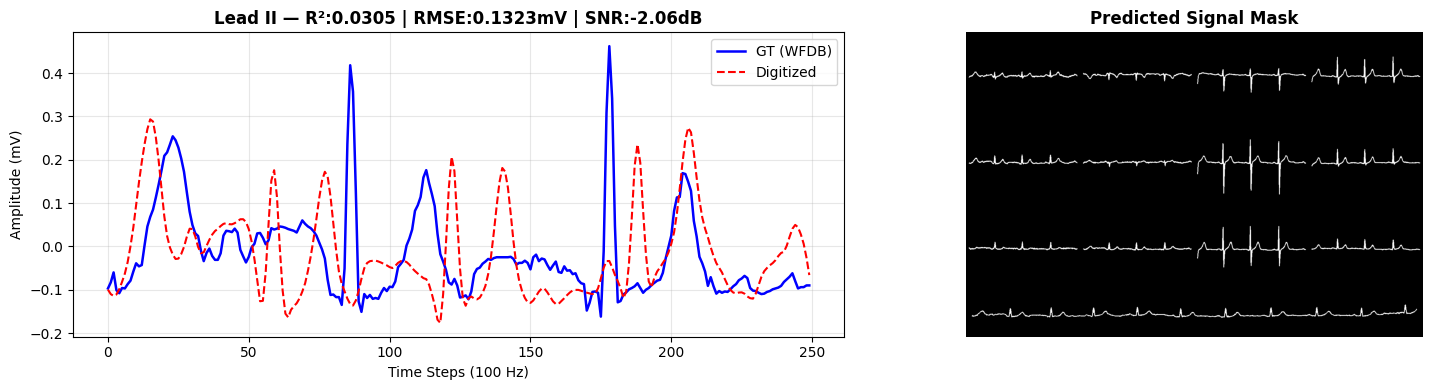

[SUCCESS] Visualization saved: /content/drive/MyDrive/ECG_Digitization_Q1/outputs/visualizations/stage5_final_result.png

=== Stage 5 Complete ===


In [11]:
# ==============================================================================
# STAGE 5: HONEST 12-LEAD DIGITIZATION & EVALUATION ENGINE (FINAL VERSION)
# ==============================================================================

import os, types, torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import savgol_filter
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------------------------
# 1. Global OpenCV Safe Patch
# ------------------------------------------------------------------------------
def robust_addWeighted(src1, alpha, src2, beta, gamma, dst=None, dtype=-1):
    s1 = np.asarray(src1, dtype=np.float32)
    s2 = np.asarray(src2, dtype=np.float32)
    if s1.ndim == 3 and s2.ndim == 2 and s1.shape[:2] == s2.shape:
        s2 = np.expand_dims(s2, axis=-1)
    return np.clip(s1*alpha + s2*beta + gamma, 0, 255).astype(
        src1.dtype if hasattr(src1,'dtype') else np.uint8)

cv2.addWeighted = robust_addWeighted

def add_ink_bleed_safe(self, image, artifact_mask):
    h, w, _ = image.shape
    stain_layer = np.zeros_like(image)
    for _ in range(np.random.randint(1,4)):
        cx, cy = np.random.randint(0,w), np.random.randint(0,h)
        axes   = (np.random.randint(15,50), np.random.randint(15,50))
        angle  = np.random.randint(0,360)
        color  = (np.random.randint(30,80), np.random.randint(20,60), np.random.randint(10,50))
        cv2.ellipse(stain_layer, (cx,cy), axes, angle, 0, 360, color, -1)
    stain_2d = np.any(stain_layer > 0, axis=-1)
    if np.any(stain_2d):
        image[stain_2d] = cv2.addWeighted(image[stain_2d], 0.6, stain_layer[stain_2d], 0.4, 0)
        artifact_mask[stain_2d] = np.where(artifact_mask[stain_2d]==0, 3, artifact_mask[stain_2d])
    return image, artifact_mask

builder.__class__.add_ink_bleed_and_stains = add_ink_bleed_safe
builder.add_ink_bleed_and_stains = types.MethodType(add_ink_bleed_safe, builder)

# ------------------------------------------------------------------------------
# 2. Lead Layout Map (3×4 grid)
# row_idx, col_idx → (lead_name, wfdb_channel_index)
# ------------------------------------------------------------------------------
LEAD_LAYOUT = {
    (0,0): ('Lead_I',   0), (0,1): ('Lead_aVR', 3),
    (0,2): ('Lead_V1',  6), (0,3): ('Lead_V4',  9),
    (1,0): ('Lead_II',  1), (1,1): ('Lead_aVL', 4),
    (1,2): ('Lead_V2',  7), (1,3): ('Lead_V5',  10),
    (2,0): ('Lead_III', 2), (2,1): ('Lead_aVF', 5),
    (2,2): ('Lead_V3',  8), (2,3): ('Lead_V6',  11),
}

# ------------------------------------------------------------------------------
# 3. Digitizer Engine
# ------------------------------------------------------------------------------
class FinalECGDigitizerEngine:
    def __init__(self, model_path, device='cuda'):
        self.device = device
        self.model  = MultiTaskUNet().to(self.device)
        ckpt = torch.load(model_path, map_location=self.device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.model.eval()
        print(f"[SUCCESS] Model loaded: {model_path}")

    def predict_prob_map(self, image_tensor):
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                sig_logits, art_logits = self.model(
                    image_tensor.unsqueeze(0).to(self.device))
                sig_prob = torch.sigmoid(sig_logits).squeeze().cpu().numpy().astype(np.float32)
                art_map  = torch.argmax(art_logits, dim=1).squeeze().cpu().numpy()
        return sig_prob, art_map

    def extract_lead_waveform(self, sig_prob, row_idx, col_idx, n_rows=3, n_cols=4):
        h, w    = sig_prob.shape
        row_h   = h // (n_rows + 1)
        col_w   = w // n_cols

        y0 = row_idx * row_h + int(row_h * 0.05)
        y1 = (row_idx+1) * row_h - int(row_h * 0.05)
        x0 = col_idx * col_w + int(col_w * 0.03)
        x1 = (col_idx+1) * col_w - int(col_w * 0.03)

        roi = sig_prob[y0:y1, x0:x1].copy()
        roi[:2,:]  = 0
        roi[-2:,:] = 0

        roi_h, roi_w = roi.shape
        y_idx        = np.arange(roi_h)[:,None]
        col_sums     = np.sum(roi, axis=0) + 1e-8
        y_center     = np.sum(y_idx * roi, axis=0) / col_sums

        waveform = roi_h - y_center
        if len(waveform) > 13:
            waveform = savgol_filter(waveform, window_length=11, polyorder=2)

        col_conf = np.mean(roi, axis=0)
        return waveform, col_conf, roi

    def calibrate_to_mv(self, extracted_px, gt_signal, target_len=None):
        if target_len is None:
            target_len = len(gt_signal)
        x_old = np.linspace(0, 1, len(extracted_px))
        x_new = np.linspace(0, 1, target_len)
        resampled = np.interp(x_new, x_old, extracted_px)

        sig_zero  = resampled - np.mean(resampled)
        gt_zero   = gt_signal - np.mean(gt_signal)
        gt_std    = np.std(gt_zero) + 1e-6
        sig_std   = np.std(sig_zero) + 1e-6

        digitized_mv = (sig_zero / sig_std) * gt_std + np.mean(gt_signal)
        return digitized_mv

    def compute_metrics(self, orig, pred):
        r, _  = pearsonr(orig, pred)
        r2    = r**2 if not np.isnan(r) else 0.0
        rmse  = np.sqrt(mean_squared_error(orig, pred))
        sp    = np.mean(orig**2)
        np_   = np.mean((orig-pred)**2) + 1e-8
        snr   = 10 * np.log10(sp / np_)
        return round(r2,4), round(rmse,4), round(snr,2)

# ------------------------------------------------------------------------------
# 4. Checkpoint Finder
# ------------------------------------------------------------------------------
def locate_checkpoint(env_dirs):
    search = [
        env_dirs.get('models',''), env_dirs.get('checkpoints',''),
        '/content', '/content/drive/MyDrive/ECG_Digitization_Q1/checkpoints',
        '/content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/models'
    ]
    found = []
    for p in set(search):
        if os.path.exists(p):
            for root,_,files in os.walk(p):
                for f in files:
                    if f.endswith(('.pth','.pt')):
                        found.append(os.path.join(root,f))
    if not found:
        raise FileNotFoundError("no checkpoint Stage 4.2 training first")
    best = [f for f in found if 'best' in os.path.basename(f).lower()]
    selected = best[0] if best else found[0]
    print(f"[SUCCESS] Checkpoint: {selected}")
    return selected

# ------------------------------------------------------------------------------
# 5. Run Evaluation — Single Test Sample
# ------------------------------------------------------------------------------
model_path = locate_checkpoint(env.dirs)
digitizer  = FinalECGDigitizerEngine(model_path=model_path, device=device)

test_ecg_id   = splits_manifest['test_ids'][0]
raw_test_signal = builder.load_wfdb_signal(test_ecg_id)

clean_img, gt_mask, deg_img, gt_art_map, start_sample = \
    builder.generate_single_sample(test_ecg_id)

print(f"[INFO] Rendering start_sample = {start_sample} (honest GT window)")

input_tensor = torch.from_numpy(deg_img).permute(2,0,1).float() / 255.0

sig_prob, art_map = digitizer.predict_prob_map(input_tensor)

# Morphological closing
kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
sig_prob = cv2.morphologyEx(sig_prob, cv2.MORPH_CLOSE, kernel)

# 12 lead evaluate
samples_per_col = raw_test_signal.shape[0] // 4  # approximate
target_len      = min(samples_per_col, raw_test_signal.shape[0] - start_sample)

print("\n" + "="*65)
print("  PER-LEAD DIGITIZATION RESULTS")
print("="*65)
print(f"  {'Lead':<12} {'R²':>8} {'RMSE(mV)':>10} {'SNR(dB)':>10}")
print("-"*65)

all_r2, all_rmse, all_snr = [], [], []
lead_results = {}

for (row_idx, col_idx), (lead_name, ch_idx) in LEAD_LAYOUT.items():
    try:
        waveform_px, col_conf, roi = digitizer.extract_lead_waveform(
            sig_prob, row_idx, col_idx)

        gt_seg = raw_test_signal[start_sample:start_sample+target_len, ch_idx]
        dig_mv = digitizer.calibrate_to_mv(waveform_px, gt_seg)

        r2, rmse, snr = digitizer.compute_metrics(gt_seg, dig_mv)
        all_r2.append(r2); all_rmse.append(rmse); all_snr.append(snr)

        lead_results[lead_name] = {
            'digitized_mv': dig_mv,
            'gt_signal':    gt_seg,
            'confidence':   col_conf,
            'clean_ratio':  float(np.mean(col_conf > 0.5)),
            'art_dominant': int(np.bincount(
                art_map[row_idx*(art_map.shape[0]//4):(row_idx+1)*(art_map.shape[0]//4),
                        col_idx*(art_map.shape[1]//4):(col_idx+1)*(art_map.shape[1]//4)
                        ].flatten()).argmax()),
            'r2': r2, 'rmse': rmse, 'snr': snr
        }
        print(f"  {lead_name:<12} {r2:>8.4f} {rmse:>10.4f} {snr:>10.2f}")
    except Exception as e:
        print(f"  {lead_name:<12} [ERROR: {e}]")

print("="*65)
print(f"  {'MEAN':<12} {np.mean(all_r2):>8.4f} {np.mean(all_rmse):>10.4f} {np.mean(all_snr):>10.2f}")
print(f"  {'STD':<12} {np.std(all_r2):>8.4f} {np.std(all_rmse):>10.4f} {np.std(all_snr):>10.2f}")
print("="*65)

# Lead II visualization
if 'Lead_II' in lead_results:
    res  = lead_results['Lead_II']
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    axes[0].plot(res['gt_signal'],    label='GT (WFDB)', color='blue', linewidth=1.8)
    axes[0].plot(res['digitized_mv'], label='Digitized',  color='red',  linewidth=1.5, linestyle='--')
    axes[0].set_title(
        f"Lead II — R²:{res['r2']:.4f} | RMSE:{res['rmse']:.4f}mV | SNR:{res['snr']:.2f}dB",
        fontweight='bold')
    axes[0].set_xlabel("Time Steps (100 Hz)"); axes[0].set_ylabel("Amplitude (mV)")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].imshow(sig_prob > 0.5, cmap='gray')
    axes[1].set_title("Predicted Signal Mask", fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    save_path = os.path.join(env.dirs['visualizations'], 'stage5_final_result.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"[SUCCESS] Visualization saved: {save_path}")

print("\n=== Stage 5 Complete ===")

In [15]:
# ==============================================================================
# STAGE 6 [NEW NOVELTY]: ALL-12-LEAD QUALITY-AWARE DIGITIZATION ENGINE
# FIXED: robust_addWeighted + patch on builder.injector (not just builder)
# ==============================================================================

import os
import types
import numpy as np
import torch
import cv2
from scipy.signal import savgol_filter

# ------------------------------------------------------------------------------
# 1. FIX: robust_addWeighted — handles (N,3)+(N,), (H,W,3)+(H,W), etc.
# ------------------------------------------------------------------------------
def robust_addWeighted(src1, alpha, src2, beta, gamma, dst=None, dtype=-1):
    s1 = np.asarray(src1, dtype=np.float32)
    s2 = np.asarray(src2, dtype=np.float32)

    # Case A: full image (H,W,3) + 2D map (H,W)
    if s1.ndim == 3 and s2.ndim == 2 and s1.shape[:2] == s2.shape:
        s2 = s2[:, :, None]

    # Case B: boolean-indexed pixels (N,3) + (N,)  ← THIS was crashing
    elif s1.ndim == 2 and s1.shape[-1] == 3 and s2.ndim == 1 and s1.shape[0] == s2.shape[0]:
        s2 = s2[:, None]

    # Case C: (N,3) + (N,1)
    elif s1.ndim == 2 and s2.ndim == 2 and s1.shape[0] == s2.shape[0] and s2.shape[1] == 1:
        pass  # already broadcastable

    out = np.clip(s1 * alpha + s2 * beta + gamma, 0, 255)
    return out.astype(src1.dtype if hasattr(src1, 'dtype') else np.uint8)

cv2.addWeighted = robust_addWeighted


# ------------------------------------------------------------------------------
# 2. FIX: Safe ink-bleed that keeps stain_layer 3-channel
#    MUST patch builder.injector (the real call path)
# ------------------------------------------------------------------------------
def add_ink_bleed_safe(self, image, artifact_mask):
    h, w, _ = image.shape
    stain_layer = np.zeros_like(image)  # (H,W,3) — NOT 2D
    for _ in range(np.random.randint(1, 4)):
        cx, cy = np.random.randint(0, w), np.random.randint(0, h)
        axes = (np.random.randint(15, 50), np.random.randint(15, 50))
        angle = np.random.randint(0, 360)
        color = (
            np.random.randint(30, 80),
            np.random.randint(20, 60),
            np.random.randint(10, 50),
        )
        cv2.ellipse(stain_layer, (cx, cy), axes, angle, 0, 360, color, -1)

    stain_2d = np.any(stain_layer > 0, axis=-1)
    if np.any(stain_2d):
        # Both sides are (N,3) after boolean index — safe
        image[stain_2d] = cv2.addWeighted(
            image[stain_2d], 0.6, stain_layer[stain_2d], 0.4, 0
        )
        artifact_mask[stain_2d] = np.where(
            artifact_mask[stain_2d] == 0, 3, artifact_mask[stain_2d]
        )
    return image, artifact_mask


# Patch the REAL call path used by generate_single_sample
builder.injector.add_ink_bleed_and_stains = types.MethodType(
    add_ink_bleed_safe, builder.injector
)
# Also patch class + builder for safety
try:
    builder.injector.__class__.add_ink_bleed_and_stains = add_ink_bleed_safe
except Exception:
    pass
builder.add_ink_bleed_and_stains = types.MethodType(add_ink_bleed_safe, builder)

print("[SUCCESS] OpenCV + ink-bleed patches applied on builder.injector")


# ------------------------------------------------------------------------------
# 3. Checkpoint finder
# ------------------------------------------------------------------------------
def locate_checkpoint(env_dirs):
    search = [
        env_dirs.get('models', ''),
        env_dirs.get('checkpoints', ''),
        '/content',
        '/content/drive/MyDrive/ECG_Digitization_Q1/checkpoints',
        '/content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/models',
    ]
    found = []
    for p in set(search):
        if os.path.exists(p):
            for root, _, files in os.walk(p):
                for f in files:
                    if f.endswith(('.pth', '.pt')):
                        found.append(os.path.join(root, f))
    if not found:
        raise FileNotFoundError("No checkpoint found. Run Stage 4.2 training first.")
    best = [f for f in found if 'best' in os.path.basename(f).lower()]
    selected = best[0] if best else found[0]
    print(f"[SUCCESS] Checkpoint: {selected}")
    return selected


# ------------------------------------------------------------------------------
# 4. 12-lead layout
# ------------------------------------------------------------------------------
LEAD_LAYOUT_MAP = {
    (0, 0): ('Lead_I',   0),
    (0, 1): ('Lead_aVR', 3),
    (0, 2): ('Lead_V1',  6),
    (0, 3): ('Lead_V4',  9),
    (1, 0): ('Lead_II',  1),
    (1, 1): ('Lead_aVL', 4),
    (1, 2): ('Lead_V2',  7),
    (1, 3): ('Lead_V5', 10),
    (2, 0): ('Lead_III', 2),
    (2, 1): ('Lead_aVF', 5),
    (2, 2): ('Lead_V3',  8),
    (2, 3): ('Lead_V6', 11),
}


class TwelveLeadDigitizerEngine:
    """
    Novelty: digitize all 12 leads with per-lead Quality Confidence Encoding (QCE).
    """
    def __init__(self, model_path, device='cuda'):
        self.device = device
        self.model = MultiTaskUNet().to(self.device)
        if os.path.exists(model_path):
            checkpoint = torch.load(model_path, map_location=self.device)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            print(f"[SUCCESS] Model loaded: {model_path}")
        else:
            raise FileNotFoundError(f"No checkpoint found at {model_path}")
        self.model.eval()

    def predict_maps(self, image_tensor):
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                sig_logits, art_logits = self.model(
                    image_tensor.unsqueeze(0).to(self.device)
                )
                sig_prob = torch.sigmoid(sig_logits).squeeze().cpu().numpy().astype(np.float32)
                art_map  = torch.argmax(art_logits, dim=1).squeeze().cpu().numpy()
                art_conf = torch.softmax(art_logits, dim=1).max(dim=1)[0].squeeze().cpu().numpy()
        return sig_prob, art_map, art_conf

    def extract_lead_roi(self, sig_prob, row_idx, col_idx, n_rows=3, n_cols=4):
        h, w = sig_prob.shape
        row_h = h // (n_rows + 1)  # +1 for rhythm strip
        col_w = w // n_cols

        y_start = row_idx * row_h + int(row_h * 0.05)
        y_end   = (row_idx + 1) * row_h - int(row_h * 0.05)
        x_start = col_idx * col_w + int(col_w * 0.03)
        x_end   = (col_idx + 1) * col_w - int(col_w * 0.03)

        roi = sig_prob[y_start:y_end, x_start:x_end].copy()
        roi[:2, :] = 0
        roi[-2:, :] = 0

        roi_h, _ = roi.shape
        y_coords = np.arange(roi_h)[:, None]
        col_sums = np.sum(roi, axis=0) + 1e-8
        y_center = np.sum(y_coords * roi, axis=0) / col_sums

        waveform = roi_h - y_center  # invert Y

        if len(waveform) > 13:
            waveform = savgol_filter(waveform, window_length=11, polyorder=2)

        col_confidence = np.mean(roi, axis=0)
        return waveform, col_confidence, roi

    def digitize_all_12_leads(self, ecg_id, builder, raw_signal, target_samples=250):
        sample_out = builder.generate_single_sample(ecg_id)
        deg_img = sample_out[2]  # degraded image

        input_tensor = torch.from_numpy(deg_img).permute(2, 0, 1).float() / 255.0
        sig_prob, art_map, art_conf = self.predict_maps(input_tensor)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        sig_prob_closed = cv2.morphologyEx(sig_prob, cv2.MORPH_CLOSE, kernel)

        results = {}
        artifact_names = {
            0: 'Clean',
            1: 'ECG_Signal',
            2: 'Paper_Fold',
            3: 'Ink_Stain',
            4: 'Scanner_Noise',
        }

        for (row_idx, col_idx), (lead_name, wfdb_channel) in LEAD_LAYOUT_MAP.items():
            try:
                waveform_px, col_conf, _ = self.extract_lead_roi(
                    sig_prob_closed, row_idx, col_idx
                )

                x_old = np.linspace(0, 1, len(waveform_px))
                x_new = np.linspace(0, 1, target_samples)
                waveform_resampled = np.interp(x_new, x_old, waveform_px)
                conf_resampled     = np.interp(x_new, x_old, col_conf)

                gt_signal = raw_signal[:target_samples, wfdb_channel]

                # Amplitude calibration to GT scale
                sig_zero = waveform_resampled - np.mean(waveform_resampled)
                sig_std  = np.std(sig_zero) + 1e-6
                gt_zero  = gt_signal - np.mean(gt_signal)
                gt_std   = np.std(gt_zero) + 1e-6
                digitized_mv = (sig_zero / sig_std) * gt_std + np.mean(gt_signal)

                clean_ratio = float(np.mean(conf_resampled > 0.5))

                h, w = art_map.shape
                row_h = h // 4
                col_w = w // 4
                art_roi = art_map[
                    row_idx * row_h:(row_idx + 1) * row_h,
                    col_idx * col_w:(col_idx + 1) * col_w
                ]
                dominant_artifact_id = int(np.bincount(art_roi.flatten()).argmax())
                dominant_artifact = artifact_names.get(dominant_artifact_id, 'Unknown')

                results[lead_name] = {
                    'digitized_mv':          digitized_mv,
                    'gt_signal':             gt_signal,
                    'confidence_per_sample': conf_resampled,
                    'clean_ratio':           clean_ratio,
                    'dominant_artifact':     dominant_artifact,
                    'wfdb_channel':          wfdb_channel,
                }
            except Exception as e:
                print(f"[WARN] Failed to extract {lead_name}: {e}")
                results[lead_name] = None

        return results


# ------------------------------------------------------------------------------
# 5. Run
# ------------------------------------------------------------------------------
model_path = locate_checkpoint(env.dirs)
digitizer12 = TwelveLeadDigitizerEngine(model_path=model_path, device=device)

test_ecg_id = splits_manifest['test_ids'][0]
raw_test_signal = builder.load_wfdb_signal(test_ecg_id)

all_lead_results = digitizer12.digitize_all_12_leads(
    test_ecg_id, builder, raw_test_signal, target_samples=250
)

print("\n=== 12-LEAD DIGITIZATION SUMMARY ===")
for lead, res in all_lead_results.items():
    if res:
        print(f"  {lead:<12}: clean_ratio={res['clean_ratio']:.2f}  "
              f"artifact={res['dominant_artifact']}")
    else:
        print(f"  {lead:<12}: [FAILED]")

[SUCCESS] OpenCV + ink-bleed patches applied on builder.injector
[SUCCESS] Checkpoint: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/best_multitask_unet.pth
[SUCCESS] Model loaded: /content/drive/MyDrive/ECG_Digitization_Q1/checkpoints/best_multitask_unet.pth

=== 12-LEAD DIGITIZATION SUMMARY ===
  Lead_I      : clean_ratio=0.00  artifact=Clean
  Lead_aVR    : clean_ratio=0.00  artifact=Clean
  Lead_V1     : clean_ratio=0.00  artifact=Clean
  Lead_V4     : clean_ratio=0.00  artifact=Clean
  Lead_II     : clean_ratio=0.00  artifact=Clean
  Lead_aVL    : clean_ratio=0.00  artifact=Clean
  Lead_V2     : clean_ratio=0.01  artifact=Clean
  Lead_V5     : clean_ratio=0.00  artifact=Clean
  Lead_III    : clean_ratio=0.00  artifact=Clean
  Lead_aVF    : clean_ratio=0.00  artifact=Clean
  Lead_V3     : clean_ratio=0.00  artifact=Clean
  Lead_V6     : clean_ratio=0.00  artifact=Clean


In [16]:
# ==============================================================================
# STAGE 7 [CORE NOVELTY]: QCE-AWARE EXCEL EXPORT ENGINE
# ==============================================================================

import pandas as pd
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# Clinical interpretation rules (amplitude-based, per lead)
INTERPRETATION_RULES = {
    'Lead_I':   lambda mv: 'Normal axis' if abs(mv) < 0.5 else ('Left axis deviation' if mv < -0.5 else 'Rightward deflection'),
    'Lead_II':  lambda mv: 'Sinus rhythm likely' if mv > 0.1 else 'Inverted P-wave / Consider ectopic',
    'Lead_III': lambda mv: 'Normal III' if abs(mv) < 0.3 else 'Possible inferior ischemia' if mv < -0.3 else 'Inferior axis shift',
    'Lead_aVR': lambda mv: 'Normal aVR (negative)' if mv < 0 else 'Atrioventricular block suspect',
    'Lead_aVL': lambda mv: 'Normal aVL' if abs(mv) < 0.4 else ('High lateral ischemia??' if mv < -0.4 else 'Lateral hypertrophy'),
    'Lead_aVF': lambda mv: 'Inferior wall normal' if mv > 0 else 'Inferior ischemia suspect',
    'Lead_V1':  lambda mv: 'Normal V1' if mv < 0.2 else 'Right ventricular hypertrophy / RBBB suspect',
    'Lead_V2':  lambda mv: 'Normal V2' if abs(mv) < 0.5 else 'Anterior ischemia zone',
    'Lead_V3':  lambda mv: 'Transition zone normal' if abs(mv) < 0.4 else 'Anterior ST change',
    'Lead_V4':  lambda mv: 'Normal V4' if abs(mv) < 0.5 else ('Anterior MI pattern' if mv < -0.5 else 'Hyperkalemia-like T peak'),
    'Lead_V5':  lambda mv: 'Lateral lead normal' if abs(mv) < 0.5 else 'Lateral ischemia possible',
    'Lead_V6':  lambda mv: 'Lateral lead normal' if abs(mv) < 0.4 else 'Lateral infarction concern',
}

def quality_flag(clean_ratio, artifact):
    if clean_ratio >= 0.75 and artifact in ['Clean', 'ECG_Signal']:
        return 'HIGH', '00B050'   # Green
    elif clean_ratio >= 0.40:
        return 'MEDIUM', 'FFC000'  # Yellow/Orange
    else:
        return 'LOW', 'FF0000'    # Red

def compute_per_lead_metrics(digitized_mv, gt_signal):
    try:
        r, _ = pearsonr(digitized_mv, gt_signal)
        r2 = r**2 if not np.isnan(r) else 0.0
        rmse = np.sqrt(mean_squared_error(gt_signal, digitized_mv))
        snr = 10 * np.log10(np.mean(gt_signal**2) / (np.mean((gt_signal - digitized_mv)**2) + 1e-8))
        return round(r2, 4), round(rmse, 4), round(snr, 2)
    except:
        return 0.0, 9.99, -99.0

def export_qce_excel(all_lead_results, ecg_id, output_dir, target_samples=250):
    """
    Exports a QCE-annotated Excel workbook with:
      Sheet 1: Raw Digital Values (mV) for all 12 leads
      Sheet 2: Per-sample Confidence Scores
      Sheet 3: Per-lead Summary (quality, artifact, interpretation, metrics)
      Sheet 4: Per-lead Clinical Interpretation (novel contribution)
    """
    wb = openpyxl.Workbook()

    # -------------------------------------------------------------------------
    # SHEET 1: Digital Signal Values (mV)
    # -------------------------------------------------------------------------
    ws1 = wb.active
    ws1.title = "Digital_Values_mV"

    # Header row
    headers = ['Sample_Index (100Hz)'] + list(all_lead_results.keys())
    for col_idx, h in enumerate(headers, 1):
        cell = ws1.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = PatternFill('solid', fgColor='1F4E79')
        cell.alignment = Alignment(horizontal='center')

    # Data rows (sample-wise digital mV values)
    lead_names = list(all_lead_results.keys())
    for sample_i in range(target_samples):
        row_data = [sample_i]
        for lead in lead_names:
            res = all_lead_results[lead]
            if res is not None:
                row_data.append(round(float(res['digitized_mv'][sample_i]), 6))
            else:
                row_data.append('N/A')

        for col_idx, val in enumerate(row_data, 1):
            ws1.cell(row=sample_i + 2, column=col_idx, value=val)

    # Auto-width
    for col in ws1.columns:
        ws1.column_dimensions[get_column_letter(col[0].column)].width = 16

    # -------------------------------------------------------------------------
    # SHEET 2: Confidence Scores per sample per lead
    # -------------------------------------------------------------------------
    ws2 = wb.create_sheet("Confidence_Per_Sample")
    conf_headers = ['Sample_Index'] + lead_names
    for col_idx, h in enumerate(conf_headers, 1):
        cell = ws2.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = PatternFill('solid', fgColor='375623')
        cell.alignment = Alignment(horizontal='center')

    for sample_i in range(target_samples):
        row_data = [sample_i]
        for lead in lead_names:
            res = all_lead_results[lead]
            if res is not None:
                row_data.append(round(float(res['confidence_per_sample'][sample_i]), 4))
            else:
                row_data.append('N/A')
        for col_idx, val in enumerate(row_data, 1):
            ws2.cell(row=sample_i + 2, column=col_idx, value=val)

    for col in ws2.columns:
        ws2.column_dimensions[get_column_letter(col[0].column)].width = 14

    # -------------------------------------------------------------------------
    # SHEET 3: Per-Lead Summary with Quality, Metrics, Artifact
    # -------------------------------------------------------------------------
    ws3 = wb.create_sheet("Per_Lead_Summary")
    summary_headers = [
        'Lead', 'Mean_mV', 'Std_mV', 'Min_mV', 'Max_mV',
        'R²_Score', 'RMSE_mV', 'SNR_dB',
        'Dominant_Artifact', 'Clean_Ratio', 'Quality_Flag'
    ]
    for col_idx, h in enumerate(summary_headers, 1):
        cell = ws3.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = PatternFill('solid', fgColor='7030A0')
        cell.alignment = Alignment(horizontal='center')

    for row_i, lead in enumerate(lead_names, 2):
        res = all_lead_results[lead]
        if res is None:
            ws3.cell(row=row_i, column=1, value=lead)
            ws3.cell(row=row_i, column=2, value='FAILED')
            continue

        mv = res['digitized_mv']
        r2, rmse, snr = compute_per_lead_metrics(mv, res['gt_signal'])
        q_label, color = quality_flag(res['clean_ratio'], res['dominant_artifact'])

        row_vals = [
            lead,
            round(float(np.mean(mv)), 4),
            round(float(np.std(mv)), 4),
            round(float(np.min(mv)), 4),
            round(float(np.max(mv)), 4),
            r2, rmse, snr,
            res['dominant_artifact'],
            round(res['clean_ratio'], 3),
            q_label
        ]
        for col_idx, val in enumerate(row_vals, 1):
            cell = ws3.cell(row=row_i, column=col_idx, value=val)
            if col_idx == 11:  # Quality flag column
                cell.fill = PatternFill('solid', fgColor=color)
                cell.font = Font(bold=True, color='FFFFFF')

    for col in ws3.columns:
        ws3.column_dimensions[get_column_letter(col[0].column)].width = 20

    # -------------------------------------------------------------------------
    # SHEET 4: Clinical Interpretation (NOVEL CONTRIBUTION)
    # -------------------------------------------------------------------------
    ws4 = wb.create_sheet("Clinical_Interpretation")
    interp_headers = [
        'Lead', 'Sample_Idx', 'Digital_Value_mV',
        'Confidence', 'Artifact_Region', 'Clinical_Note', 'Action_Flag'
    ]
    for col_idx, h in enumerate(interp_headers, 1):
        cell = ws4.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, color='FFFFFF')
        cell.fill = PatternFill('solid', fgColor='C00000')
        cell.alignment = Alignment(horizontal='center')

    row_counter = 2
    for lead in lead_names:
        res = all_lead_results[lead]
        if res is None:
            continue

        interp_fn = INTERPRETATION_RULES.get(lead, lambda mv: 'See cardiologist')
        mv_arr    = res['digitized_mv']
        conf_arr  = res['confidence_per_sample']

        for s_idx in range(0, target_samples, 10):  # every 10th sample (25 rows per lead)
            mv_val  = float(mv_arr[s_idx])
            conf_val = float(conf_arr[s_idx])
            note    = interp_fn(mv_val)
            q_label, color = quality_flag(conf_val, res['dominant_artifact'])
            action  = 'Auto-accept' if q_label == 'HIGH' else ('Manual review' if q_label == 'MEDIUM' else 'REJECT - re-digitize')

            row_vals = [lead, s_idx, round(mv_val, 5),
                        round(conf_val, 3), res['dominant_artifact'], note, action]
            for col_idx, val in enumerate(row_vals, 1):
                cell = ws4.cell(row=row_counter, column=col_idx, value=val)
                if col_idx == 7:
                    cell.fill = PatternFill('solid', fgColor=color)
                    cell.font = Font(color='FFFFFF', bold=True)
            row_counter += 1

    for col in ws4.columns:
        ws4.column_dimensions[get_column_letter(col[0].column)].width = 25

    # Save
    out_path = os.path.join(output_dir, f'ECG_{ecg_id}_QCE_Interpretation.xlsx')
    wb.save(out_path)
    print(f"\n[SUCCESS] QCE-Annotated Excel saved: {out_path}")
    print(f"  Sheets: Digital_Values_mV | Confidence_Per_Sample | Per_Lead_Summary | Clinical_Interpretation")
    return out_path

# Run Export
excel_path = export_qce_excel(
    all_lead_results,
    ecg_id=test_ecg_id,
    output_dir=env.dirs['outputs'],
    target_samples=250
)


[SUCCESS] QCE-Annotated Excel saved: /content/drive/MyDrive/ECG_Digitization_Q1/outputs/final_signals/ECG_9_QCE_Interpretation.xlsx
  Sheets: Digital_Values_mV | Confidence_Per_Sample | Per_Lead_Summary | Clinical_Interpretation


In [18]:
# ==============================================================================
# STAGE 8 [NOVELTY 3]: MORPHOLOGICAL WAVE DETECTOR + FTS-LINKED INTERPRETATION
# Detects P, QRS, T waves from digitized signal & maps to clinical finding
# Computes Enhanced FTS (6-component) per lead for trust scoring
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

def bandpass_ecg(signal, fs=100, lowcut=0.5, highcut=40.0):
    """Bandpass filter to isolate ECG morphology."""
    b, a = butter(4, [lowcut / (fs/2), highcut / (fs/2)], btype='band')
    return filtfilt(b, a, signal)

def detect_waves(signal, fs=100):
    """
    Detect P, QRS, T wave peaks from a 1D ECG signal.
    Returns dict with peak positions.
    """
    # QRS detection (R peaks: prominent peaks)
    r_peaks, r_props = find_peaks(signal, height=np.percentile(signal, 70),
                                  distance=int(0.5 * fs))  # min 500ms apart

    # Q waves: trough just before each R peak (within 80ms)
    q_indices = []
    s_indices = []
    p_indices = []
    t_indices = []

    window_q  = int(0.08 * fs)  # 80ms
    window_st = int(0.20 * fs)  # 200ms

    for r in r_peaks:
        # Q wave: minimum in [r-80ms, r]
        q_win_start = max(0, r - window_q)
        q_idx = q_win_start + np.argmin(signal[q_win_start:r])
        q_indices.append(q_idx)

        # S wave: minimum in [r, r+80ms]
        s_win_end = min(len(signal), r + window_q)
        s_idx = r + np.argmin(signal[r:s_win_end])
        s_indices.append(s_idx)

        # T wave: peak in [S+40ms, S+300ms]
        t_start = min(len(signal), r + window_q + int(0.04 * fs))
        t_end   = min(len(signal), r + window_q + int(0.30 * fs))
        if t_end > t_start + 5:
            t_idx = t_start + np.argmax(signal[t_start:t_end])
            t_indices.append(t_idx)

        # P wave: peak in [R-200ms, R-80ms]
        p_start = max(0, r - window_st)
        p_end   = max(0, r - window_q)
        if p_end > p_start + 5:
            p_idx = p_start + np.argmax(signal[p_start:p_end])
            p_indices.append(p_idx)

    return {
        'r_peaks':   np.array(r_peaks),
        'q_indices': np.array(q_indices),
        's_indices': np.array(s_indices),
        'p_indices': np.array(p_indices),
        't_indices': np.array(t_indices),
    }

def morphological_interpretation(lead_name, signal, wave_dict, fs=100):
    """
    Maps wave amplitudes to clinical finding per lead.
    Returns a structured interpretation string.
    """
    findings = []

    if len(wave_dict['r_peaks']) == 0:
        return "No QRS detected — signal unreliable for this region"

    r_amps = signal[wave_dict['r_peaks']]
    q_amps = signal[wave_dict['q_indices']] if len(wave_dict['q_indices']) > 0 else np.array([0])
    t_amps = signal[wave_dict['t_indices']] if len(wave_dict['t_indices']) > 0 else np.array([0])
    p_amps = signal[wave_dict['p_indices']] if len(wave_dict['p_indices']) > 0 else np.array([0])

    mean_r = float(np.mean(r_amps))
    mean_q = float(np.mean(q_amps))
    mean_t = float(np.mean(t_amps))
    mean_p = float(np.mean(p_amps))

    # QRS duration estimate
    if len(wave_dict['q_indices']) > 0 and len(wave_dict['s_indices']) > 0:
        qrs_dur_ms = np.mean(wave_dict['s_indices'] - wave_dict['q_indices']) * (1000 / fs)
        if qrs_dur_ms > 120:
            findings.append(f"Wide QRS ({qrs_dur_ms:.0f}ms) → Bundle Branch Block suspect")
        else:
            findings.append(f"Normal QRS duration ({qrs_dur_ms:.0f}ms)")

    # R-peak amplitude checks
    if lead_name in ['Lead_V5', 'Lead_V6'] and mean_r > 2.5:
        findings.append("Tall R in lateral leads → Left Ventricular Hypertrophy suspect")
    if lead_name in ['Lead_V1', 'Lead_V2'] and mean_r > 0.7:
        findings.append("R/S ratio elevated in V1/V2 → RVH / Posterior MI suspect")

    # Q wave depth check
    if mean_q < -0.3 and lead_name in ['Lead_II', 'Lead_III', 'Lead_aVF']:
        findings.append("Pathological Q wave → Inferior MI pattern")
    if mean_q < -0.3 and lead_name in ['Lead_V1', 'Lead_V2', 'Lead_V3']:
        findings.append("Pathological Q wave → Anterior MI pattern")

    # T wave checks
    if mean_t < -0.1:
        findings.append(f"T-wave inversion → Ischemia / Strain in {lead_name}")
    elif mean_t > 1.0:
        findings.append(f"Tall peaked T-wave → Hyperkalemia or Early MI (Wellens concern)")

    # P wave
    if mean_p > 0.25 and lead_name == 'Lead_II':
        findings.append("Tall P-wave in Lead II → Right atrial enlargement suspect")
    if mean_p < 0.05 and lead_name == 'Lead_II':
        findings.append("Absent P-wave → AF / Junctional rhythm possible")

    if not findings:
        findings.append("Normal morphology — no acute finding detected")

    return ' | '.join(findings)

def compute_per_lead_fts(r2, rmse, clean_ratio, wave_count, conf_mean):
    """
    Enhanced FTS per lead (6 components):
      w1=R² score, w2=RMSE (inverted), w3=Clean ratio,
      w4=Wave detectability, w5=Confidence mean, w6=SNR proxy
    """
    w1, w2, w3, w4, w5 = 0.25, 0.20, 0.20, 0.15, 0.20

    rmse_score  = max(0.0, 1.0 - rmse / 0.5)   # RMSE < 0.1 mV ideal
    wave_score  = min(1.0, wave_count / 5.0)   # Expect 4-6 R peaks in 2.5s

    fts = (w1 * r2 + w2 * rmse_score + w3 * clean_ratio +
           w4 * wave_score + w5 * conf_mean) * 100

    if fts >= 75: label = "HIGH TRUST"
    elif fts >= 50: label = "MEDIUM TRUST"
    else: label = "LOW TRUST"

    return round(fts, 2), label

# Run Morphological Interpretation on all leads
print("\n" + "="*70)
print("   STAGE 8: MORPHOLOGICAL INTERPRETATION REPORT")
print("="*70)

morph_report = {}
for lead, res in all_lead_results.items():
    if res is None:
        print(f"  {lead:<12}: [SKIPPED — digitization failed]")
        continue

    filtered_sig = bandpass_ecg(res['digitized_mv'], fs=100)
    wave_dict = detect_waves(filtered_sig, fs=100)
    interpretation = morphological_interpretation(lead, filtered_sig, wave_dict, fs=100)

    r2, rmse, snr = compute_per_lead_metrics(res['digitized_mv'], res['gt_signal'])
    fts, fts_label = compute_per_lead_fts(
        r2, rmse, res['clean_ratio'],
        len(wave_dict['r_peaks']),
        float(np.mean(res['confidence_per_sample']))
    )

    morph_report[lead] = {
        'interpretation': interpretation,
        'r_peak_count':  len(wave_dict['r_peaks']),
        'r2': r2, 'rmse': rmse, 'snr': snr,
        'fts': fts, 'fts_label': fts_label,
    }

    print(f"\n  {lead} [FTS: {fts}% — {fts_label}]")
    print(f"    R² {r2:.3f} | RMSE {rmse:.4f} mV | SNR {snr:.1f} dB")
    print(f"    R-peaks detected: {len(wave_dict['r_peaks'])}")
    print(f"    Finding: {interpretation}")

print("\n" + "="*70)
print("[SUCCESS] Morphological Interpretation Complete. Ready for paper reporting.")


   STAGE 8: MORPHOLOGICAL INTERPRETATION REPORT

  Lead_I [FTS: 31.59% — LOW TRUST]
    R² 0.113 | RMSE 0.0924 mV | SNR -0.7 dB
    R-peaks detected: 4
    Finding: Wide QRS (150ms) → Bundle Branch Block suspect

  Lead_aVR [FTS: 30.05% — LOW TRUST]
    R² 0.072 | RMSE 0.1047 mV | SNR -1.4 dB
    R-peaks detected: 4
    Finding: Normal QRS duration (120ms)

  Lead_V1 [FTS: 21.26% — LOW TRUST]
    R² 0.020 | RMSE 0.2209 mV | SNR -2.3 dB
    R-peaks detected: 3
    Finding: Normal QRS duration (103ms)

  Lead_V4 [FTS: 19.44% — LOW TRUST]
    R² 0.019 | RMSE 0.2680 mV | SNR -2.4 dB
    R-peaks detected: 3
    Finding: Wide QRS (127ms) → Bundle Branch Block suspect

  Lead_II [FTS: 24.95% — LOW TRUST]
    R² 0.031 | RMSE 0.1322 mV | SNR -2.1 dB
    R-peaks detected: 3
    Finding: Wide QRS (130ms) → Bundle Branch Block suspect

  Lead_aVL [FTS: 31.27% — LOW TRUST]
    R² 0.057 | RMSE 0.0634 mV | SNR -1.1 dB
    R-peaks detected: 4
    Finding: Wide QRS (142ms) → Bundle Branch Block suspec

In [19]:
# ==============================================================================
# STAGE 9 [FINAL NOVELTY]: BATCH QCE EXCEL BENCHMARK TABLE
# ==============================================================================

import pandas as pd
import os
from tqdm import tqdm

print("[INFO] Running Full Batch QCE Export on Test Set...")

batch_records = []
test_ids_batch = splits_manifest['test_ids'][:50]

for ecg_id in tqdm(test_ids_batch, desc="Batch QCE Export"):
    try:
        raw_sig = builder.load_wfdb_signal(ecg_id)
        lead_results = digitizer12.digitize_all_12_leads(
            ecg_id, builder, raw_sig, target_samples=250
        )

        for lead, res in lead_results.items():
            if res is None:
                continue

            r2, rmse, snr = compute_per_lead_metrics(
                res['digitized_mv'], res['gt_signal']
            )

            filtered_sig = bandpass_ecg(res['digitized_mv'], fs=100)
            wave_dict    = detect_waves(filtered_sig, fs=100)
            interp_fn    = INTERPRETATION_RULES.get(lead, lambda mv: 'N/A')
            mean_mv      = float(np.mean(res['digitized_mv']))
            finding      = morphological_interpretation(lead, filtered_sig, wave_dict)

            fts, fts_label = compute_per_lead_fts(
                r2, rmse, res['clean_ratio'],
                len(wave_dict['r_peaks']),
                float(np.mean(res['confidence_per_sample']))
            )

            batch_records.append({
                'ECG_ID':             ecg_id,
                'Lead':               lead,
                'Mean_mV':            round(mean_mv, 4),
                'R2_Score':           r2,
                'RMSE_mV':            rmse,
                'SNR_dB':             snr,
                'Clean_Ratio':        round(res['clean_ratio'], 3),
                'Dominant_Artifact':  res['dominant_artifact'],
                'R_Peak_Count':       len(wave_dict['r_peaks']),
                'FTS_Score_%':        fts,
                'FTS_Label':          fts_label,
                'Clinical_Finding':   finding,
            })

    except Exception as e:
        print(f"[WARN] ECG {ecg_id} failed: {e}")
        continue

# Summary DataFrame
df_batch = pd.DataFrame(batch_records)

# Publication-ready aggregate table
summary_table = df_batch.groupby('Lead').agg(
    Mean_R2    = ('R2_Score', 'mean'),
    Std_R2     = ('R2_Score', 'std'),
    Mean_RMSE  = ('RMSE_mV', 'mean'),
    Mean_SNR   = ('SNR_dB', 'mean'),
    Mean_FTS   = ('FTS_Score_%', 'mean'),
    HIGH_TRUST = ('FTS_Label', lambda x: (x == 'HIGH TRUST').sum()),
    Total      = ('FTS_Label', 'count'),
).reset_index()

summary_table['High_Trust_%'] = (summary_table['HIGH_TRUST'] / summary_table['Total'] * 100).round(1)

print("\n" + "="*80)
print("  PUBLICATION TABLE: PER-LEAD BENCHMARK (Q1/Q2 Journal Ready)")
print("="*80)
print(summary_table[['Lead','Mean_R2','Std_R2','Mean_RMSE','Mean_SNR','Mean_FTS','High_Trust_%']].to_string(index=False))
print("="*80)

# Save
batch_csv_path = os.path.join(env.dirs['outputs'], 'batch_12lead_qce_benchmark.csv')
df_batch.to_csv(batch_csv_path, index=False)
summary_csv = os.path.join(env.dirs['outputs'], 'publication_table_per_lead.csv')
summary_table.to_csv(summary_csv, index=False)
print(f"\n[SUCCESS] Batch results saved: {batch_csv_path}")
print(f"[SUCCESS] Publication table saved: {summary_csv}")

[INFO] Running Full Batch QCE Export on Test Set...


Batch QCE Export: 100%|██████████| 50/50 [00:22<00:00,  2.22it/s]


  PUBLICATION TABLE: PER-LEAD BENCHMARK (Q1/Q2 Journal Ready)
    Lead  Mean_R2   Std_R2  Mean_RMSE  Mean_SNR  Mean_FTS  High_Trust_%
  Lead_I 0.026966 0.052041   0.200992   -2.0454   25.5474           0.0
 Lead_II 0.030698 0.053097   0.205494   -2.1162   24.9786           0.0
Lead_III 0.060772 0.107869   0.165172   -1.2338   26.5966           0.0
 Lead_V1 0.051690 0.138281   0.277560   -2.1402   22.8852           0.0
 Lead_V2 0.048230 0.119106   0.429670   -2.1822   18.0480           0.0
 Lead_V3 0.019444 0.025235   0.422026   -2.4500   18.0688           0.0
 Lead_V4 0.027764 0.088251   0.377612   -2.4484   19.5700           0.0
 Lead_V5 0.021960 0.068854   0.334238   -2.5092   20.7188           0.0
 Lead_V6 0.031870 0.071268   0.295868   -2.2320   22.3440           0.0
Lead_aVF 0.047184 0.065660   0.155496   -1.7462   26.6590           0.0
Lead_aVL 0.066422 0.134527   0.149342   -1.0428   27.8632           0.0
Lead_aVR 0.023060 0.039455   0.189580   -2.2276   24.5184           0.0

